# IMPORT

In [27]:
!pip install python-binance

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [28]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

import matplotlib.pyplot as plt

from binance.client import Client
from datetime import datetime, timezone


# CONFIG

In [29]:


SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

#TICKER = "AAPL"
#START = "2018-01-01"
#END = None

TRAIN_FRAC = 0.8

# Trading / reward parameters
FEE = 0.0005         # transaction cost per unit position change
KAPPA = 0.1          # risk penalty weight
INITIAL_BUDGET = 100000.0  # Starting capital in USDT

# PPO hyperparameters (optimized for stable trading)
num_envs = 8
n_steps = 128  # Back to original
total_updates = 2000  # Back to 2000 for proper convergence

gamma = 0.99
gae_lambda = 0.95

lr = 1e-4  # Reduced from 3e-4 for stability
vf_coef = 0.5
ent_coef = 0.01  # Increased from 0.001 for more exploration
max_grad_norm = 0.5

clip_eps = 0.2
ppo_epochs = 10  # Back to 10
minibatch_size = 64  # Back to 64
target_kl = 0.1

# HELPER FUNCTIONS AND CLASSES

In [30]:
from binance.client import Client
import pandas as pd
from datetime import datetime, timezone

def load_ohlcv(ticker="BTCUSDT", start="1 Jan, 2017", end=None, interval="1d"):

    client = Client()

    # Mapping interval
    interval_map = {
        "1d": Client.KLINE_INTERVAL_1DAY,
        "1h": Client.KLINE_INTERVAL_1HOUR,
        "4h": Client.KLINE_INTERVAL_4HOUR
    }

    binance_interval = interval_map.get(interval, Client.KLINE_INTERVAL_1DAY)

    # Si pas de end → jusqu’à aujourd’hui
    if end is None:
        end = datetime.now(timezone.utc).strftime("%d %b, %Y")

    klines = client.get_historical_klines(
        ticker,
        binance_interval,
        start,
        end
    )

    columns = [
        "open_time",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_time",
        "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base",
        "taker_buy_quote",
        "ignore"
    ]

    df = pd.DataFrame(klines, columns=columns)

    # Date index
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    df = df.set_index("open_time")
    df.index.name = "Date"

    # Garder uniquement les colonnes du screenshot
    df = df[["open", "high", "low", "close", "volume"]]

    # Convertir en float
    df = df.astype(float)
    df = df.dropna()

    return df

# Load BTCUSDT data from Binance
print("Loading BTCUSDT data from Binance (this may take 30-60 seconds)...")
import time
start_time = time.time()
df = load_ohlcv("BTCUSDT", "1 Jan, 2023")  # Recent data only (3 years instead of 8)
load_time = time.time() - start_time
print(f"✅ Loaded {len(df)} days of BTCUSDT data in {load_time:.1f}s")
print(f"Date range: {df.index[0]} to {df.index[-1]}")
df.head()

Loading BTCUSDT data from Binance (this may take 30-60 seconds)...
✅ Loaded 1160 days of BTCUSDT data in 1.3s
Date range: 2023-01-01 00:00:00 to 2026-03-05 00:00:00


,open,high,low,close,volume
Date,,,,,
2023-01-01,16541.77,16628.00,16499.01,16616.75,96925.41374
2023-01-02,16617.17,16799.23,16548.70,16672.87,121888.57191
2023-01-03,16672.78,16778.40,16605.28,16675.18,159541.53733
2023-01-04,16675.65,16991.87,16652.66,16850.36,220362.18862
2023-01-05,16850.36,16879.82,16753.00,16831.85,163473.56641


## Feature engineering + toy forecasting features

Complete with previous forecast - Teil 1 Projekt  if needed

In [31]:
def add_features_and_forecast(df, ewma_span=20, vol_window=20):
    df = df.copy()
    df["log_close"] = np.log(df["close"])
    df["r"] = df["log_close"].diff()

    # Forecast signal (toy): EWMA mean of returns
    df["mu_hat"] = df["r"].ewm(span=ewma_span, adjust=False).mean()

    # Risk estimate: rolling volatility
    df["sigma_hat"] = df["r"].rolling(vol_window).std()

    # Lag features
    df["r_lag1"] = df["r"].shift(1)

    # Add RSI for additional signal
    delta = df["close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-8)
    df["rsi"] = 100 - (100 / (1 + rs))
    df["rsi"] = (df["rsi"] - 50) / 50  # Normalize to [-1, 1]

    # Add MACD
    ema12 = df["log_close"].ewm(span=12, adjust=False).mean()
    ema26 = df["log_close"].ewm(span=26, adjust=False).mean()
    df["macd"] = ema12 - ema26
    df["macd"] = (df["macd"] - df["macd"].mean()) / (df["macd"].std() + 1e-8)  # Normalize

    df = df.dropna()
    return df

df_feat = add_features_and_forecast(df)
df_feat.head()

,open,high,low,close,volume,log_close,r,mu_hat,sigma_hat,r_lag1,rsi,macd
Date,,,,,,,,,,,,
2023-01-21,22666.00,23371.80,22422.00,22783.55,346445.48432,10.033794,0.005119,0.016513,0.023884,0.072994,0.831529,2.215600
2023-01-22,22783.35,23078.71,22292.37,22707.88,253577.75286,10.030467,-0.003327,0.014624,0.024113,0.005119,0.806997,2.303213
2023-01-23,22706.02,23180.00,22500.00,22916.45,293588.37938,10.039610,0.009143,0.014102,0.023895,-0.003327,0.811312,2.367118
2023-01-24,22917.81,23162.20,22462.93,22632.89,293158.78254,10.027159,-0.012451,0.011573,0.024705,0.009143,0.731930,2.352895
2023-01-25,22631.94,23816.73,22300.00,23060.94,346042.83223,10.045896,0.018736,0.012255,0.024432,-0.012451,0.729083,2.362582


## Train/Test split (time-based)

In [32]:
n = len(df_feat)
split = int(TRAIN_FRAC * n)

df_train = df_feat.iloc[:split].reset_index(drop=True)
df_test  = df_feat.iloc[split:].reset_index(drop=True)

print(len(df_train), len(df_test))

912 228


## Trading Environment (target position action)

In [33]:
class TradingEnv(gym.Env):
    """
    Enhanced trading environment with budget/liquidity tracking and refined long/short.
    - Action: target position a_t in [-1, 1]
    - Reward: normalized pnl - transaction_cost - risk_penalty + direction_bonus
    - State: market features + portfolio features (including budget/liquidity)
    - Enhanced with cumulative profit tracking and refined leverage constraints
    """
    metadata = {"render_modes": []}

    def __init__(self, df, fee=0.0005, kappa=0.1, initial_budget=100000.0, max_leverage=2.0):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.fee = float(fee)
        self.kappa = float(kappa)
        self.initial_budget = float(initial_budget)
        self.max_leverage = float(max_leverage)

        # Action = target position a_t in [-1, 1]
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)

        # Market + forecast features + enhanced portfolio features
        self.feature_cols = ["r", "r_lag1", "mu_hat", "sigma_hat", "rsi", "macd"]
        # obs_dim = market_features(6) + pos(1) + equity_norm(1) + drawdown(1) + liquidity_ratio(1) + leverage(1)
        obs_dim = len(self.feature_cols) + 5
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t = 1  # start from 1 because we use r_t
        self.pos = 0.0  # Position (fraction of capital)
        self.equity = self.initial_budget
        self.initial_equity = self.initial_budget
        self.peak = self.initial_budget
        self.cumulative_profit = 0.0  # Track absolute profit
        self.cost_accumulated = 0.0   # Track total transaction costs
        return self._get_obs(), {}

    def _get_obs(self):
        # Market features
        x = self.df.loc[self.t, self.feature_cols].values.astype(np.float32)

        # Portfolio features
        equity_norm = np.float32(self.equity / self.initial_budget)  # Normalized equity
        drawdown = np.float32((self.peak - self.equity) / (self.peak + 1e-8))

        # Liquidity ratio: how much free capital available
        position_value = abs(self.pos) * self.equity
        free_capital = self.equity - position_value
        liquidity_ratio = np.float32(max(0.0, free_capital) / (self.equity + 1e-8))

        # Current leverage (absolute exposure / equity)
        leverage = np.float32(abs(self.pos) * self.max_leverage)

        obs = np.concatenate([x, np.array([self.pos, equity_norm, drawdown, liquidity_ratio, leverage], dtype=np.float32)])
        return obs

    def step(self, action):
        a = float(np.clip(action[0], -1.0, 1.0))

        r_t = float(self.df.loc[self.t, "r"])
        sigma_t = float(self.df.loc[self.t, "sigma_hat"])
        if not np.isfinite(sigma_t) or sigma_t < 0.0001:
            sigma_t = 0.01

        # === CORRECTED REWARD CALCULATION ===
        # 1. Calculate actual PnL in dollars from current position and return
        #    r_t is log return, so real return is exp(r_t) - 1
        real_return = np.exp(r_t) - 1.0  # Convert log return to real return
        pnl_dollars = self.pos * self.equity * real_return

        # Scale to reward range [-0.1, +0.1]
        pnl_reward = np.tanh(pnl_dollars / self.initial_budget) * 0.05  # Normalize by initial budget

        # 2. Transaction cost penalty
        position_change = abs(a - self.pos)
        transaction_cost = self.fee * position_change * self.equity
        cost_reward = -np.tanh(transaction_cost / self.initial_budget) * 0.01

        # 3. Risk penalty: penalize big positions in high volatility
        risk_reward = -0.01 * (a ** 2) * sigma_t

        # 4. Stability bonus: reward being flat in uncertain markets
        mu_hat = float(self.df.loc[self.t, "mu_hat"])
        if abs(mu_hat) < 0.0001:  # Uncertain market
            stability_bonus = 0.002 * (1.0 - abs(a))
        else:
            stability_bonus = 0.0

        # Total reward
        reward = pnl_reward + cost_reward + risk_reward + stability_bonus

        # === UPDATE EQUITY (CLEAN METHOD) ===
        # Update equity with actual PnL and costs
        self.equity = self.equity + pnl_dollars - transaction_cost
        self.cumulative_profit += pnl_dollars
        self.cost_accumulated += transaction_cost

        # Safety: ensure equity stays positive (with lower bound at 10% of initial)
        if self.equity <= self.initial_budget * 0.1:
            self.equity = self.initial_budget * 0.1
            reward -= 0.05  # Extra penalty for hitting lower bound

        # Update position
        self.pos = a
        self.peak = max(self.peak, self.equity)

        # Time step
        self.t += 1
        terminated = (self.t >= len(self.df) - 1)
        truncated = False

        return self._get_obs(), float(reward), terminated, truncated, {
            "cumulative_profit": self.cumulative_profit,
            "equity": self.equity,
            "position": self.pos,
            "costs": self.cost_accumulated,
            "pnl_dollars": pnl_dollars,
            "transaction_cost": transaction_cost
        }

## Vectorized env (train)

In [34]:
def make_env(df):
    def thunk():
        return TradingEnv(df, fee=FEE, kappa=KAPPA, initial_budget=INITIAL_BUDGET, max_leverage=2.0)
    return thunk

env = gym.vector.SyncVectorEnv([make_env(df_train) for _ in range(num_envs)])
obs_dim = env.single_observation_space.shape[0]
act_dim = env.single_action_space.shape[0]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("obs_dim:", obs_dim, "act_dim:", act_dim, "device:", device)

obs_dim: 11 act_dim: 1 device: cpu


## PPO model (Gaussian policy + tanh squash + corrected logprob)

In [35]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        # ...existing code...
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU()
        )
        self.mu = nn.Linear(64, act_dim)
        self.log_std = nn.Parameter(torch.ones(act_dim) * -0.5)  # Start with std=0.6
        self.v = nn.Linear(64, 1)

        # Better initialization
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                nn.init.constant_(layer.bias, 0)

    def forward(self, obs):
        # ...existing code...
        x = self.net(obs)
        mu = torch.tanh(self.mu(x))  # Constrain mu to [-1, 1]
        std = torch.exp(torch.clamp(self.log_std, -2.0, 0.0))  # Stable std
        dist = Normal(mu, std)
        value = self.v(x).squeeze(-1)
        return dist, value

def squash(u):
    return torch.tanh(u)  # maps to [-1,1]
# main formula:
# a = f(u)
# log p(a) = log p(u) - log |det(Jacobian)|
# log p(a) ist die gesuchte policy log pi(a|a)

# we have f = tanh
# a = tanh(u)
# da/du = 1 - tanh(u)^2
# da/du = 1 - a²
# we need: log |det(Jacobian)|
# we get: log |det(Jacobian)| = log(1 - tanh(u)^2)
# in code: log_det = torch.log(1.0 - torch.tanh(u).pow(2) + eps).sum(-1)

def logprob_squashed(dist, u):
    # log p(u)
    logp_u = dist.log_prob(u).sum(-1)
    # change-of-variables for tanh
    eps = 1e-6
    log_det = torch.log(1.0 - torch.tanh(u).pow(2) + eps).sum(-1)
    return logp_u - log_det

## GAE

In [36]:
def compute_gae(rewards, dones, values, last_value, gamma=0.99, lam=0.95):
    """
    rewards: [T, N]
    dones:   [T, N] (1.0 means terminal boundary for bootstrap mask)
    values:  [T, N]
    last_value: [N]
    """
    T, N = rewards.shape
    adv = torch.zeros(T, N, device=values.device)
    gae = torch.zeros(N, device=values.device)

    for t in reversed(range(T)):
        not_done = 1.0 - dones[t]
        next_value = last_value if t == T - 1 else values[t + 1]
        delta = rewards[t] + gamma * next_value * not_done - values[t]
        gae = delta + gamma * lam * not_done * gae
        adv[t] = gae

    returns = adv + values
    return returns, adv

# TRAINING

## PPO training loop

In [37]:
model = ActorCritic(obs_dim, act_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

obs, _ = env.reset(seed=SEED)
obs = torch.as_tensor(obs, dtype=torch.float32, device=device)

ep_returns = np.zeros(num_envs, dtype=np.float32)
ep_history = []

for update in range(total_updates):
    # Rollout buffers
    obs_buf  = torch.zeros(n_steps, num_envs, obs_dim, device=device)
    u_buf    = torch.zeros(n_steps, num_envs, act_dim, device=device)
    logp_buf = torch.zeros(n_steps, num_envs, device=device)
    rew_buf  = torch.zeros(n_steps, num_envs, device=device)
    done_buf = torch.zeros(n_steps, num_envs, device=device)
    val_buf  = torch.zeros(n_steps, num_envs, device=device)

    for t in range(n_steps):
        obs_buf[t] = obs
        with torch.no_grad():
          dist, value = model(obs)
          u = dist.sample()
          a = squash(u)
          logp = logprob_squashed(dist, u)

        u_buf[t] = u
        logp_buf[t] = logp.detach()
        val_buf[t] = value.detach()

        next_obs, reward, terminated, truncated, infos = env.step(a.detach().cpu().numpy())
        done_env = np.logical_or(terminated, truncated)
        done_boot = terminated  # bootstrap mask (for time-limit envs you may choose terminated only)

        rew_buf[t] = torch.as_tensor(reward, dtype=torch.float32, device=device)
        done_buf[t] = torch.as_tensor(done_boot, dtype=torch.float32, device=device)

        # Episode return tracking
        ep_returns += reward
        if done_env.any():
            finished = np.where(done_env)[0]
            ep_history.extend(ep_returns[finished].tolist())
            ep_returns[finished] = 0.0

        obs = torch.as_tensor(next_obs, dtype=torch.float32, device=device)

    # Bootstrap last value
    with torch.no_grad():
        _, last_value = model(obs)

    returns, adv = compute_gae(rew_buf, done_buf, val_buf, last_value, gamma=gamma, lam=gae_lambda)

    # Flatten
    B = n_steps * num_envs
    obs_batch  = obs_buf.reshape(B, obs_dim)
    u_batch    = u_buf.reshape(B, act_dim)
    old_logp   = logp_buf.reshape(B)
    old_value  = val_buf.reshape(B)      # important for value clipping if you add it later
    ret_batch  = returns.reshape(B).detach()
    adv_batch  = adv.reshape(B).detach()

    # Advantage normalization
    adv_batch = (adv_batch - adv_batch.mean()) / (adv_batch.std() + 1e-8)

    idx = torch.arange(B, device=device)
    stop = False

    for _ in range(ppo_epochs):
        perm = idx[torch.randperm(B)]
        for start in range(0, B, minibatch_size):
            mb = perm[start:start + minibatch_size]

            dist, value = model(obs_batch[mb])
            logp = logprob_squashed(dist, u_batch[mb])
            entropy = dist.entropy().sum(-1)

            # Early stop by approximate KL (minibatch estimate)
            approx_kl = (old_logp[mb] - logp).mean().detach()
            if approx_kl.item() > target_kl:
                stop = True
                break

            ratio = torch.exp(logp - old_logp[mb])

            # Clipped policy objective
            unclipped = ratio * adv_batch[mb]
            clipped = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv_batch[mb]
            policy_loss = -torch.min(unclipped, clipped).mean()

            # Value loss (simple version; you can add value clipping later)
            value_loss = (ret_batch[mb] - value).pow(2).mean()

            # Entropy bonus
            entropy_loss = -entropy.mean()

            loss = policy_loss + vf_coef * value_loss + ent_coef * entropy_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

        if stop:
            break

        # Keep std in a sane range (helps prevent wild exploration collapse/explosion)
        with torch.no_grad():
            model.log_std.clamp_(-2.0, -0.5)

    if update % 100 == 0:
        mean_100 = np.mean(ep_history[-100:]) if len(ep_history) >= 100 else np.nan
        print(f"Update {update:4d} | mean_return(last100) {mean_100:8.1f} | log_std {model.log_std.data.cpu().numpy()}")

Update    0 | mean_return(last100)      nan | log_std [-0.5043985]
Update  100 | mean_return(last100)     -0.0 | log_std [-0.7004501]
Update  200 | mean_return(last100)      0.0 | log_std [-0.85541964]
Update  300 | mean_return(last100)      0.0 | log_std [-1.0841737]
Update  400 | mean_return(last100)      0.0 | log_std [-1.2847531]
Update  500 | mean_return(last100)      0.1 | log_std [-1.4907936]
Update  600 | mean_return(last100)      0.1 | log_std [-1.64531]
Update  700 | mean_return(last100)      0.1 | log_std [-1.7410649]
Update  800 | mean_return(last100)      0.2 | log_std [-1.86897]
Update  900 | mean_return(last100)      0.2 | log_std [-1.910298]
Update 1000 | mean_return(last100)      0.2 | log_std [-1.9177983]
Update 1100 | mean_return(last100)      0.1 | log_std [-1.9897567]
Update 1200 | mean_return(last100)      0.1 | log_std [-1.9983822]
Update 1300 | mean_return(last100)      0.0 | log_std [-1.9947703]
Update 1400 | mean_return(last100)      0.2 | log_std [-2.]
Update

# EVALUATION

## Evaluation on test set (single env, deterministic actions)

In [38]:
def eval_policy(model, df_eval, episodes=5):
    env_eval = TradingEnv(df_eval, fee=FEE, kappa=KAPPA, initial_budget=INITIAL_BUDGET, max_leverage=2.0)
    returns = []

    for _ in range(episodes):
        obs, _ = env_eval.reset()
        done = False
        ep_ret = 0.0

        while not done:
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                dist, _ = model(obs_t)
                # Deterministic: use mean action (mu), then squash
                u = dist.mean
                a = squash(u).cpu().numpy()[0]

            obs, reward, terminated, truncated, _ = env_eval.step(a)
            done = terminated or truncated
            ep_ret += reward

        returns.append(ep_ret)

    return float(np.mean(returns))

test_score = eval_policy(model, df_test, episodes=10)
print("EVAL mean episode reward:", test_score)

EVAL mean episode reward: -0.03172732146388424


# PLOT

## Equity curve plot (test set, one run)

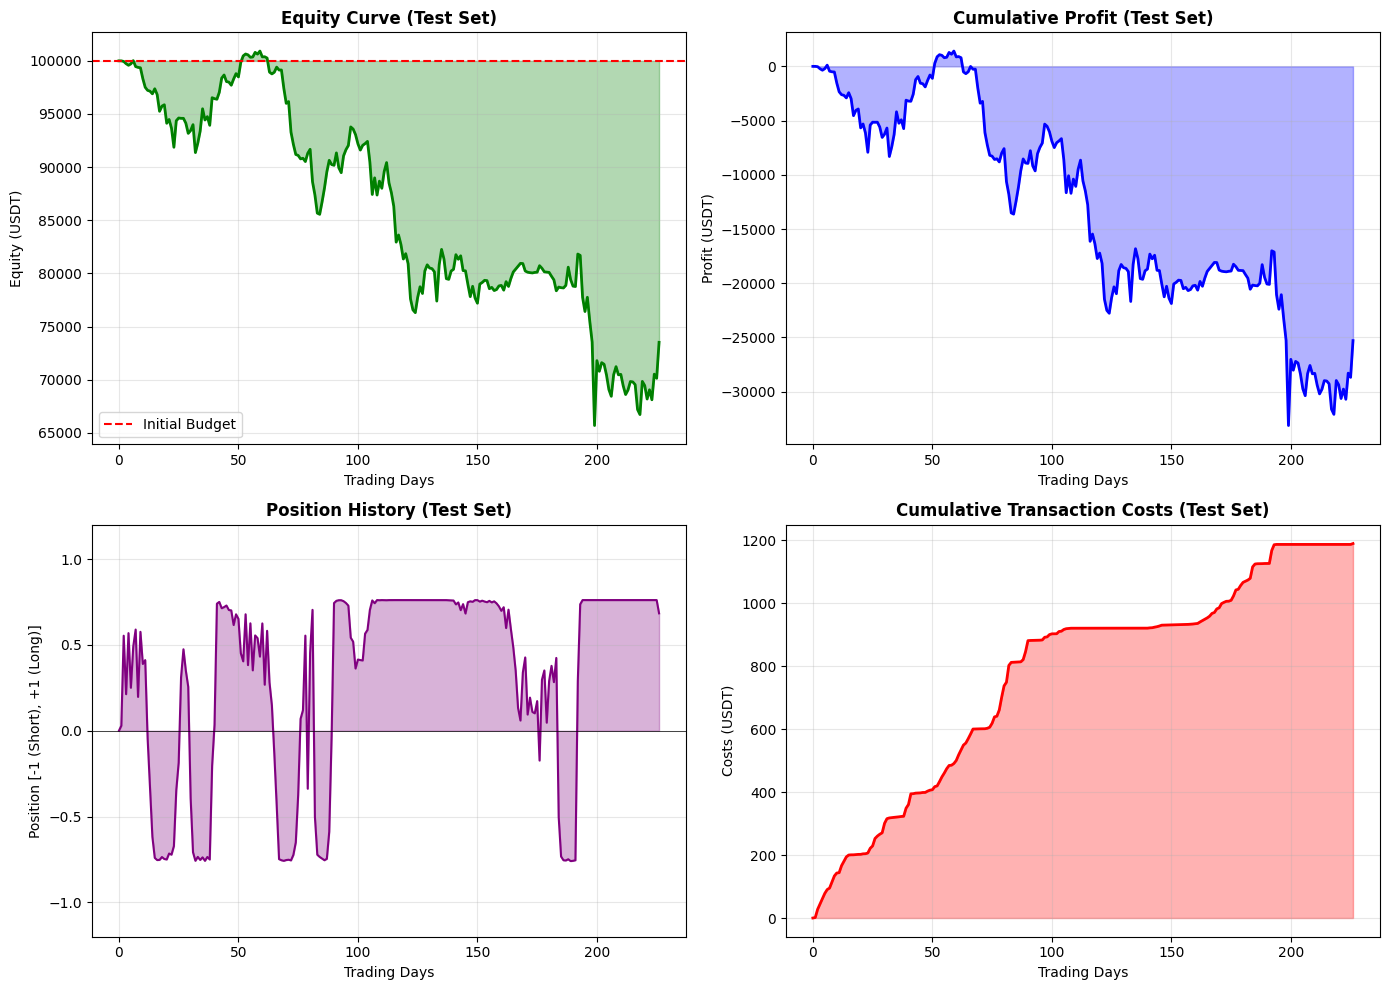

TRADING PERFORMANCE SUMMARY
Initial Budget: $100,000.00
Final Equity: $73,522.00
Total Profit: $-25,288.74
Total Costs: $1,189.26
Return: -26.48%
Max Drawdown: 34.30%
Sharpe Ratio: -11.3051


In [39]:
def run_equity_curve(model, df_eval):
    env_eval = TradingEnv(df_eval, fee=FEE, kappa=KAPPA, initial_budget=INITIAL_BUDGET, max_leverage=2.0)
    obs, _ = env_eval.reset()
    done = False

    equity = [env_eval.equity]
    pos_hist = [env_eval.pos]
    profit_hist = [0.0]  # Track cumulative profit
    cost_hist = [0.0]    # Track cumulative costs

    while not done:
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            dist, _ = model(obs_t)
            u = dist.mean
            a = squash(u).cpu().numpy()[0]

        obs, reward, terminated, truncated, info = env_eval.step(a)
        done = terminated or truncated
        equity.append(env_eval.equity)
        pos_hist.append(env_eval.pos)
        profit_hist.append(info["cumulative_profit"])
        cost_hist.append(info["costs"])

    return np.array(equity), np.array(pos_hist), np.array(profit_hist), np.array(cost_hist)

equity, pos_hist, profit_hist, cost_hist = run_equity_curve(model, df_test)

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Equity Curve
axes[0, 0].plot(equity, linewidth=2, color='green')
axes[0, 0].fill_between(range(len(equity)), INITIAL_BUDGET, equity, alpha=0.3, color='green')
axes[0, 0].axhline(y=INITIAL_BUDGET, color='red', linestyle='--', label='Initial Budget')
axes[0, 0].set_title("Equity Curve (Test Set)", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("Trading Days")
axes[0, 0].set_ylabel("Equity (USDT)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Cumulative Profit
axes[0, 1].plot(profit_hist, linewidth=2, color='blue')
axes[0, 1].fill_between(range(len(profit_hist)), 0, profit_hist, alpha=0.3, color='blue')
axes[0, 1].set_title("Cumulative Profit (Test Set)", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Trading Days")
axes[0, 1].set_ylabel("Profit (USDT)")
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Position History
axes[1, 0].plot(pos_hist, linewidth=1.5, color='purple')
axes[1, 0].fill_between(range(len(pos_hist)), 0, pos_hist, alpha=0.3, color='purple')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 0].set_title("Position History (Test Set)", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Trading Days")
axes[1, 0].set_ylabel("Position [-1 (Short), +1 (Long)]")
axes[1, 0].set_ylim([-1.2, 1.2])
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cumulative Costs
axes[1, 1].plot(cost_hist, linewidth=2, color='red')
axes[1, 1].fill_between(range(len(cost_hist)), 0, cost_hist, alpha=0.3, color='red')
axes[1, 1].set_title("Cumulative Transaction Costs (Test Set)", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Trading Days")
axes[1, 1].set_ylabel("Costs (USDT)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Summary Statistics
print("=" * 60)
print("TRADING PERFORMANCE SUMMARY")
print("=" * 60)
print(f"Initial Budget: ${INITIAL_BUDGET:,.2f}")
print(f"Final Equity: ${equity[-1]:,.2f}")
print(f"Total Profit: ${profit_hist[-1]:,.2f}")
print(f"Total Costs: ${cost_hist[-1]:,.2f}")
print(f"Return: {(equity[-1] - INITIAL_BUDGET) / INITIAL_BUDGET * 100:.2f}%")
print(f"Max Drawdown: {(1 - (equity.min() / INITIAL_BUDGET)) * 100:.2f}%")
print(f"Sharpe Ratio: {np.std(np.diff(equity)) / (np.mean(np.diff(equity)) + 1e-8) if np.mean(np.diff(equity)) != 0 else 0:.4f}")
print("=" * 60)
